# Reading the observations

In [1]:
cd /home/liaher/Documents/code/openberg_paper

/home/liaher/Documents/code/openberg_paper


In [4]:
pwd

'/home/liaher/Documents/code/openberg_paper'

In [3]:
import json
import glob
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import numpy as np

In [2]:
def plot_traj_id(df_sub_in,hue_opt='trajectory_id',palette_opt=None):

    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.NorthPolarStereo())

    # Coastlines
    ax.coastlines(resolution='10m')

    # Scatter plot
    sc = sns.scatterplot(
        data=df_sub_in,
        x='lon',
        y='lat',
        marker='o',
        hue=hue_opt,
        palette=palette_opt,      # distinct categorical colors
        edgecolor='none',     # remove white outline
        ax=ax,
        transform=ccrs.PlateCarree()
    )

    # Move legend outside
    ax.legend(
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        borderaxespad=0.
    )

    plt.tight_layout()
    plt.show()
    return

## Read individual observations

In [23]:
# --- List to collect df in ---
dfs = []

#### Read Juliette

In [24]:
trajectory_id = 'iceberg2025w'

In [25]:
# Load data
df = pd.read_csv('./observations/juliette/Osker-X2.csv', sep=';')
# Create a proper datetime column
df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],utc=True)
# Sort by time (important before grouping/subsampling)
df = df.sort_values('time')

#more xr methods
# # Convert to xarray Dataset
# ds = xr.Dataset.from_dataframe(df)
#     # Remove old time variable if present (to avoid conflict)
# try:
#     ds = ds.drop_vars('Date')
#     ds = ds.drop_vars('Time')
# except: pass
# # Set time as dimensions and coordinate
# ds = ds.set_coords("time")
# ds = ds.swap_dims({"index": "time"})
# ds = ds.drop_vars("index")  # optional
# # Daily subset: take first observation per day
# # ds_daily = ds.groupby("time").first()
# ds_daily = ds.resample(time="1D",origin="start_day").first() #.mean() 
# # Remove old time variable if present (to avoid conflict)
# # if 'time' in ds_daily:
# #     ds_daily = ds_daily.drop_vars('time')
# # # Rename dimension
# # ds_daily = ds_daily.rename({'date': 'time'})
# # # Convert to datetime64
# # ds_daily['time'] = pd.to_datetime(ds_daily['time'])
# # 3-day subset
# # ds_3day = ds_daily.isel(time=slice(0, None, 3))
# ds_3day = ds.resample(time="3D",origin="start_day").nearest()

df

/tmp/ipykernel_8882/3496566682.py:4: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],utc=True)


,Date,Time,lat,lon,id,time
0,24/09/2025,00:00:31,75.005907,-58.177344,1,2025-09-24 00:00:31+00:00
1,24/09/2025,06:00:31,75.010432,-58.207034,2,2025-09-24 06:00:31+00:00
2,24/09/2025,12:00:31,75.020538,-58.182394,3,2025-09-24 12:00:31+00:00
3,24/09/2025,18:00:31,75.044576,-58.171878,4,2025-09-24 18:00:31+00:00
4,25/09/2025,00:00:31,75.062925,-58.216211,5,2025-09-25 00:00:31+00:00
...,...,...,...,...,...,...
245,09/12/2025,12:00:31,71.945702,-69.169907,246,2025-12-09 12:00:31+00:00
246,09/12/2025,18:00:31,71.854861,-69.192781,247,2025-12-09 18:00:31+00:00
247,10/12/2025,00:00:31,71.755744,-69.161498,248,2025-12-10 00:00:31+00:00
248,10/12/2025,06:00:31,71.657984,-69.120986,249,2025-12-10 06:00:31+00:00


In [26]:
df_sub = df[['time', 'lat', 'lon']]
df_sub['trajectory_id'] = trajectory_id
dfs.append(df_sub)
df_sub

,time,lat,lon,trajectory_id
0,2025-09-24 00:00:31+00:00,75.005907,-58.177344,iceberg2025w
1,2025-09-24 06:00:31+00:00,75.010432,-58.207034,iceberg2025w
2,2025-09-24 12:00:31+00:00,75.020538,-58.182394,iceberg2025w
3,2025-09-24 18:00:31+00:00,75.044576,-58.171878,iceberg2025w
4,2025-09-25 00:00:31+00:00,75.062925,-58.216211,iceberg2025w
...,...,...,...,...
245,2025-12-09 12:00:31+00:00,71.945702,-69.169907,iceberg2025w
246,2025-12-09 18:00:31+00:00,71.854861,-69.192781,iceberg2025w
247,2025-12-10 00:00:31+00:00,71.755744,-69.161498,iceberg2025w
248,2025-12-10 06:00:31+00:00,71.657984,-69.120986,iceberg2025w


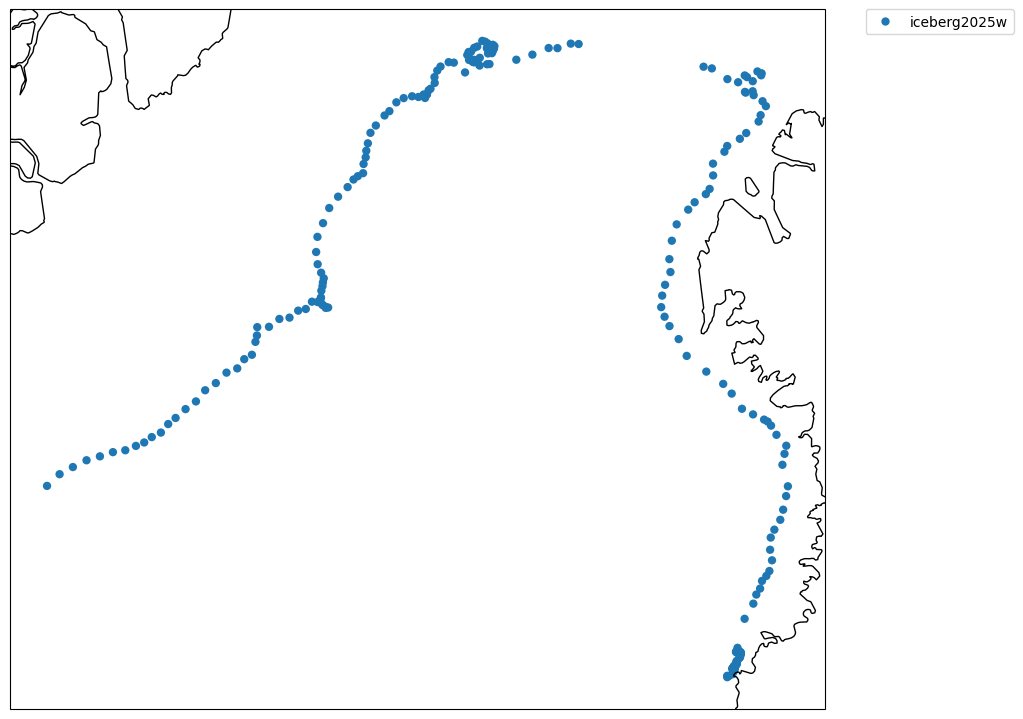

In [27]:
plot_traj_id(df_sub)

#### Read West Greenland icebergs 2011, 2012, 2021

No significant or continuous drift (therefore neglected):
- observations/west_greenland/Iceberg_6_655837_2012 and 13.csv
- observations/west_greenland/Iceberg_5_655241_2012 and 13.csv
- observations/west_greenland/003_646998_breadcrumbs.csv
- observations/west_greenland/Iceberg_7_655838_2012 and 13.csv

In [28]:
files_exclude = ["observations/west_greenland/Iceberg_6_655837_2012 and 13.csv", 
                 "observations/west_greenland/Iceberg_5_655241_2012 and 13.csv", 
                 "observations/west_greenland/003_646998_breadcrumbs.csv",
                 "observations/west_greenland/Iceberg_7_655838_2012 and 13.csv"]
files_l = glob.glob("observations/west_greenland/*.csv")
files_l = [f for f in files_l if f not in files_exclude]
cols = ['LATITUDE', 'LONGITUDE', 'ADDRESS', 'STATUS', 'DATE/TIME']
dfs_w = []
for f in files_l:
    print(f)
    df = pd.read_csv(f,
        usecols=cols if 'Iceberg' in f else None,
        engine='python',  # more tolerant of irregular files
        skiprows=7 if 'bread' in f else 0
    )
    df['time'] = pd.to_datetime(#df['DATE/TIME'],
                                # format='2012-02-11 20:32 GMT' if 'bread' in f else '%m/%d/%Y %I:%M:%S %p ')
                                df['DATE/TIME'].astype(str).str.strip(),
                                format='mixed',
                                errors='coerce',
                                utc=True)

    df = df.sort_values('time')
    df['id'] = f[28:-4]
    # print(df.head())

    # df.plot.scatter(
    #     x='LONGITUDE',
    #     y='LATITUDE',
    #     s=1
    # )
    dfs_w = dfs_w+[df]
dfs_w



observations/west_greenland/Iceberg_1_655230_2012 and 13.csv
observations/west_greenland/004_647000_breadcrumbs.csv
observations/west_greenland/005_647003_breadcrumbs.csv
observations/west_greenland/001_646995_breadcrumbs.csv
observations/west_greenland/Iceberg_3_655235_2012 and 13.csv
observations/west_greenland/Iceberg_2_655234_2012 and 13.csv
observations/west_greenland/002_646997_breadcrumps.csv
observations/west_greenland/Iceberg_4_655238_2012 and 13.csv
observations/west_greenland/008_647056_breadcrumbs.csv
observations/west_greenland/007_647050_breadcrumbs.csv
observations/west_greenland/006_647004_breadcrumbs.csv


[       LATITUDE  LONGITUDE               ADDRESS   STATUS  \
 0     72.942867 -55.586851  (72.94287,-55.58685)  STOPPED   
 1     72.942674 -55.595047  (72.94267,-55.59505)  STOPPED   
 2     72.942621 -55.602021  (72.94262,-55.60202)  STOPPED   
 3     72.942706 -55.613523  (72.94271,-55.61352)  STOPPED   
 4     72.942867 -55.625517  (72.94287,-55.62552)  STOPPED   
 ...         ...        ...                   ...      ...   
 2693  73.164546 -55.797908  (73.16455,-55.79791)  STOPPED   
 2694  73.164568 -55.797930  (73.16457,-55.79793)  STOPPED   
 2695  73.164557 -55.797865  (73.16456,-55.79787)  STOPPED   
 2696  73.164546 -55.797908  (73.16455,-55.79791)  STOPPED   
 2697  73.164568 -55.797887  (73.16457,-55.79789)  STOPPED   
 
                     DATE/TIME                      time  \
 0     08/27/2012 07:47:26 PM  2012-08-27 19:47:26+00:00   
 1     08/27/2012 08:33:58 PM  2012-08-27 20:33:58+00:00   
 2     08/27/2012 09:44:45 PM  2012-08-27 21:44:45+00:00   
 3     08/27/2

In [29]:
#combine to one dataset

df_all = pd.concat(dfs_w, ignore_index=True)
df_all = df_all.sort_values('time')
#df_all.groupby('buoy_id').resample('1D', on='DATE/TIME').mean()
df_all

,LATITUDE,LONGITUDE,ADDRESS,STATUS,DATE/TIME,time,id
19533,72.787471,-56.130052,"Rd, Upernavik, GL",STOPPED,2011-09-26 07:15 GMT,2011-09-26 07:15:00+00:00,002_646997_breadcrumps
23234,72.787396,-56.130030,"Rd, Upernavik, GL",STOPPED,2011-09-26 07:15 GMT,2011-09-26 07:15:00+00:00,006_647004_breadcrumbs
2698,72.787449,-56.129923,"Rd, Upernavik, GL",STOPPED,2011-09-26 07:21 GMT,2011-09-26 07:21:00+00:00,004_647000_breadcrumbs
5700,72.787449,-56.129987,"Rd, Upernavik, GL",STOPPED,2011-09-26 08:06 GMT,2011-09-26 08:06:00+00:00,001_646995_breadcrumbs
19534,72.787460,-56.130073,"Rd, Upernavik, GL",STOPPED,2011-09-26 08:07 GMT,2011-09-26 08:07:00+00:00,002_646997_breadcrumps
...,...,...,...,...,...,...,...
8148,NaN,NaN,NaN,NaN,Generated by Geoforce on 2012-02-20 08:26 GMT,NaT,001_646995_breadcrumbs
22540,NaN,NaN,NaN,NaN,Generated by Geoforce on 2012-02-20 08:37 GMT,NaT,002_646997_breadcrumps
23166,NaN,NaN,NaN,NaN,Generated by Geoforce on 2011-11-10 15:09 GMT,NaT,008_647056_breadcrumbs
23233,NaN,NaN,NaN,NaN,Generated by Geoforce on 2011-11-10 15:06 GMT,NaT,007_647050_breadcrumbs


In [1]:
# ids = ['007_647050_breadcrumbs','008_647056_breadcrumbs','Iceberg_4_655238_2012 and 13',]
# df_subset = df_all[df_all['id'].isin(ids)]
df_sub = df_all

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import cartopy.crs as ccrs

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Coastlines
ax.coastlines(resolution='50m')

# Scatter plot
sc = sns.scatterplot(
    data=df_sub,
    x='LONGITUDE',
    y='LATITUDE',
    marker='o',
    hue='id',
    palette='tab20',      # distinct categorical colors
    edgecolor='none',     # remove white outline
    ax=ax,
    transform=ccrs.PlateCarree()
)

# # Optional: zoom to data extent
# ax.set_extent([
#     df_all['LONGITUDE'].min() - 1,
#     df_all['LONGITUDE'].max() + 1,
#     df_all['LATITUDE'].min() - 1,
#     df_all['LATITUDE'].max() + 1
# ])

# Move legend outside
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

plt.tight_layout()
plt.show()


NameError: name 'df_all' is not defined

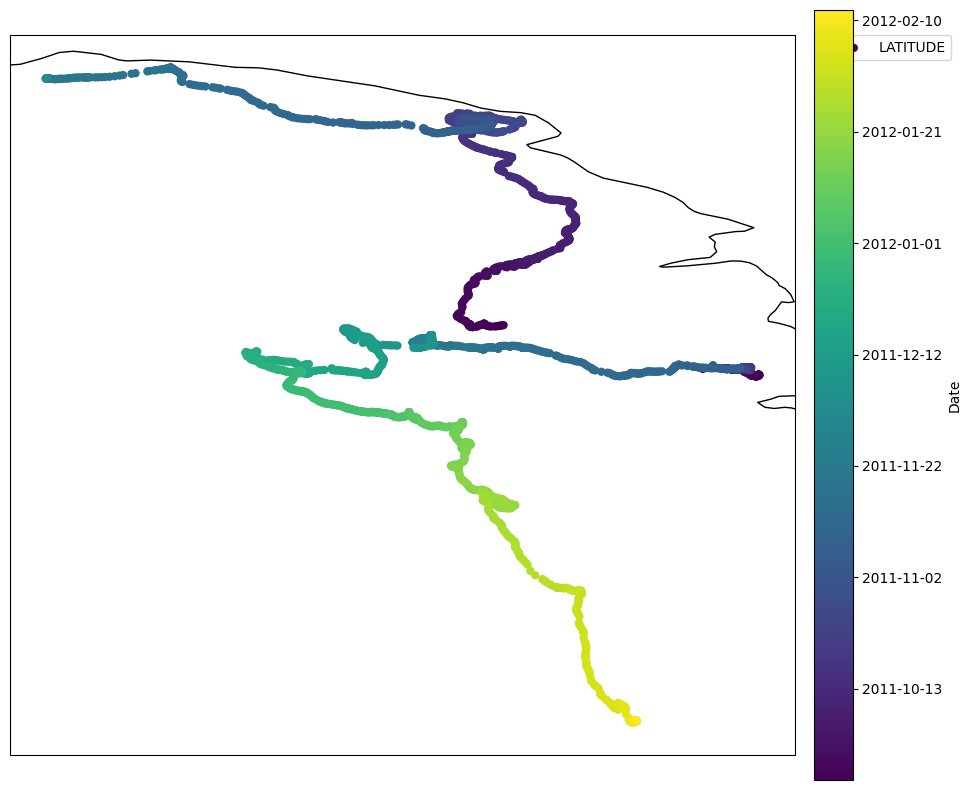

In [31]:
ids = ['001_646995_breadcrumbs','004_647000_breadcrumbs']
# ids = ['004_647000_breadcrumbs']
df_sub = df_all[df_all['id'].isin(ids)]
df_sub = df_sub.dropna(subset=['time'])
df_sub = df_sub[(df_sub['id'] != '001_646995_breadcrumbs') | (df_sub['ADDRESS'].str.startswith('(')) ]
df_sub = df_sub.drop(index=[5704, 2698, 2699, 2700, 2701],errors='ignore') #removes problematic 5704
df_sub = df_sub[
    (df_sub['id'] != '004_647000_breadcrumbs') |
    (df_sub['time'] <= pd.Timestamp('2011-12-01 T00:00:00Z')
)
]

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import cartopy.crs as ccrs

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Coastlines
ax.coastlines(resolution='50m')

# Scatter plot
sc = ax.scatter(
    data=df_sub,
    x='LONGITUDE',
    y='LATITUDE',
    marker='o',
    c=mdates.date2num(df_sub['time']),
    cmap='viridis',  # continuous colormap
    edgecolor='none',     # remove white outline
    transform=ccrs.PlateCarree()
)

#cbar if c coloured by dates
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Date')
cbar.ax.yaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m-%d')
)

# Move legend outside
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

plt.tight_layout()
plt.show()


In [32]:
df_sub = df_sub[['LATITUDE', 'LONGITUDE', 'time', 'id']].rename(columns={
    'LATITUDE': 'lat', 'LONGITUDE': 'lon', 'time': 'time', 'id': 'trajectory_id'})
df_sub['trajectory_id'] = df_sub['trajectory_id'].replace({'001_646995_breadcrumbs': 'iceberg2011w1',
                                                           '004_647000_breadcrumbs': 'iceberg2011w2'})
df_sub

,lat,lon,time,trajectory_id
2702,73.518201,-58.844082,2011-09-26 15:05:00+00:00,iceberg2011w2
5706,73.064833,-56.783245,2011-09-26 15:14:00+00:00,iceberg2011w1
2703,73.516946,-58.858523,2011-09-26 16:06:00+00:00,iceberg2011w2
2704,73.514360,-58.873544,2011-09-26 17:12:00+00:00,iceberg2011w2
2705,73.511152,-58.890109,2011-09-26 18:18:00+00:00,iceberg2011w2
...,...,...,...,...
8143,69.422854,-57.465706,2012-02-11 12:33:00+00:00,iceberg2011w1
8144,69.423305,-57.465534,2012-02-11 13:26:00+00:00,iceberg2011w1
8145,69.424678,-57.470191,2012-02-11 15:34:00+00:00,iceberg2011w1
8146,69.424571,-57.470748,2012-02-11 17:49:00+00:00,iceberg2011w1


Use trajectories:
- 001_646995 (2011) long trajectory and far enough from coast (clipped beginning, maybe clip more close to the coast)
- 004_647000 (2011) long trajectory, but close to coast (clipped beginning and end - grounded since december)

Maybe maybe: '007_647050_breadcrumbs','008_647056_breadcrumbs','Iceberg_4_655238_2012 and 13'


In [33]:
dfs.append(df_sub)
print(len(dfs))

2


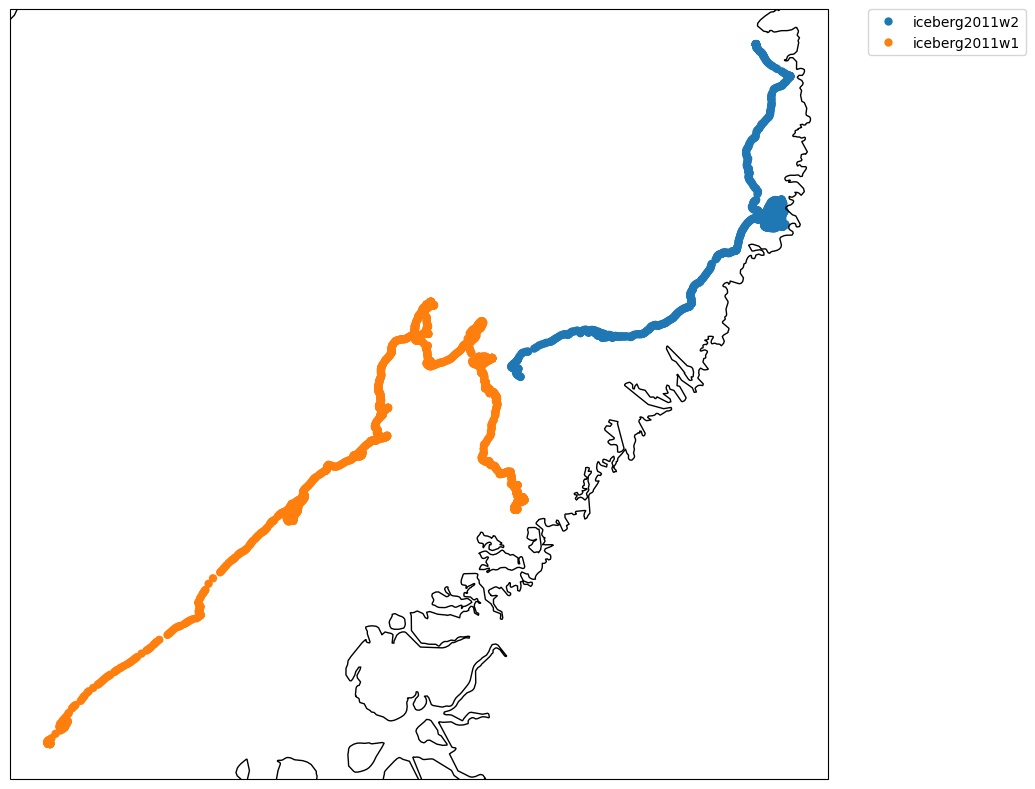

In [34]:
plot_traj_id(df_sub)

#### Read Disko Bay iceberg
Frequency of observations irregular, varies from minutes to days --> take every nth day, closest time

In [35]:
#https://drive.google.com/file/d/1OwzTwKe90XJj47MJ89LMF5NcBdo3rQLU/view 
df = pd.read_csv(
    "observations/disko_bay/11_DSE_300434065758620.dat.txt",
    sep=";",
    na_values=[-999]
)
df['time'] = (
    pd.to_datetime(df['Year'], format='%Y', utc=True)
    + pd.to_timedelta(df['DOY'] - 1, unit='D')
)
df = df.sort_values('time')

df

,BuoyID,Year,Hour,Min,DOY,POS_DOY,Lat,Lon,BP,Ts,Ta,time
0,300434065758620,2021,19,24,224.8083,224.8083,68.706970,-52.879242,1018.1077,0.0,NaN,2021-08-12 19:23:57.120000+00:00
1,300434065758620,2021,20,34,224.8569,224.8569,68.708321,-52.880779,1017.6977,0.0,NaN,2021-08-12 20:33:56.160000+00:00
2,300434065758620,2021,21,33,224.8979,224.8979,68.706879,-52.879288,1016.9913,0.0,NaN,2021-08-12 21:32:58.560000+00:00
3,300434065758620,2021,19,34,228.8153,228.8153,69.354630,-50.950008,1015.9167,0.0,NaN,2021-08-16 19:34:01.920000+00:00
4,300434065758620,2021,14,33,229.6063,229.6063,69.232826,-51.155392,1009.5085,0.0,NaN,2021-08-17 14:33:04.319999999+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
85,300434065758620,2021,1,40,289.0694,289.0694,75.461899,-59.864330,1035.1520,0.0,NaN,2021-10-16 01:39:56.160000+00:00
86,300434065758620,2021,3,58,289.1653,289.1653,75.462082,-59.865025,0.0000,0.0,NaN,2021-10-16 03:58:01.920000+00:00
87,300434065758620,2021,5,32,289.2306,289.2306,75.461891,-59.863331,0.0000,0.0,NaN,2021-10-16 05:32:03.840000+00:00
88,300434065758620,2021,6,11,289.2576,289.2576,75.461945,-59.864132,1035.3034,0.0,NaN,2021-10-16 06:10:56.640000+00:00


In [36]:
df_sub = df[['Lat', 'Lon', 'time']].rename(columns={
    'Lat': 'lat', 'Lon': 'lon', 'time': 'time'})
df_sub['trajectory_id'] = 'iceberg2021w'
df_sub

,lat,lon,time,trajectory_id
0,68.706970,-52.879242,2021-08-12 19:23:57.120000+00:00,iceberg2021w
1,68.708321,-52.880779,2021-08-12 20:33:56.160000+00:00,iceberg2021w
2,68.706879,-52.879288,2021-08-12 21:32:58.560000+00:00,iceberg2021w
3,69.354630,-50.950008,2021-08-16 19:34:01.920000+00:00,iceberg2021w
4,69.232826,-51.155392,2021-08-17 14:33:04.319999999+00:00,iceberg2021w
...,...,...,...,...
85,75.461899,-59.864330,2021-10-16 01:39:56.160000+00:00,iceberg2021w
86,75.462082,-59.865025,2021-10-16 03:58:01.920000+00:00,iceberg2021w
87,75.461891,-59.863331,2021-10-16 05:32:03.840000+00:00,iceberg2021w
88,75.461945,-59.864132,2021-10-16 06:10:56.640000+00:00,iceberg2021w


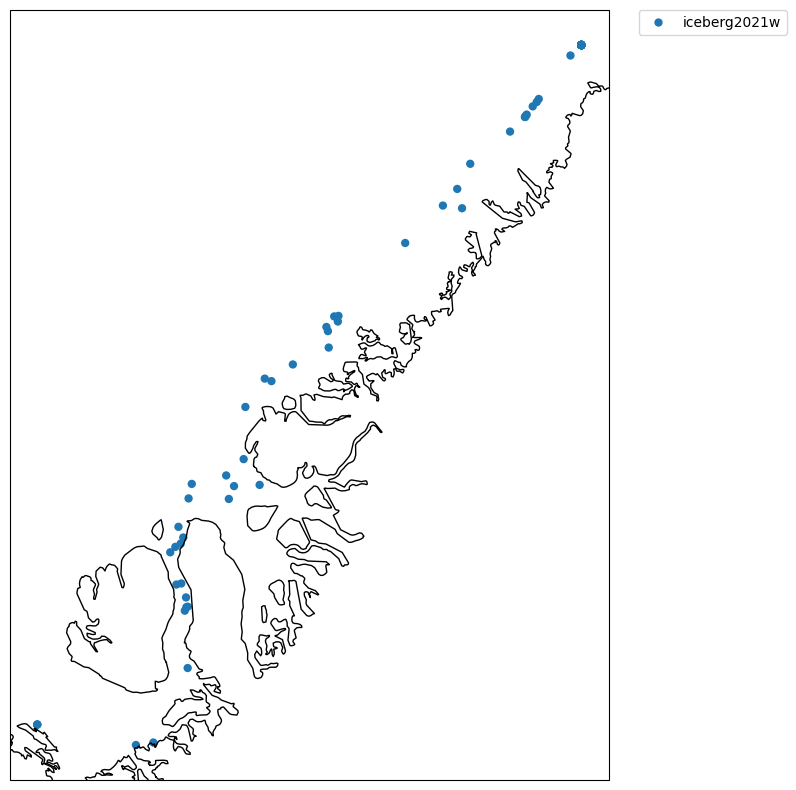

In [37]:
plot_traj_id(df_sub)

In [38]:
dfs.append(df_sub)

#### Read Baffin Bay 2017, 2018, 2021
hourly

In [39]:
#https://drive.google.com/drive/folders/1DM6jo5TcT4Y_ILzTYmbtTKk0vS2ZfeLv?usp=drive_link
files_l = glob.glob('./observations/baffin_bay_2017_2018_2021/**/*.xlsx',recursive=True)
df_all = []
for f in files_l:
    df = pd.read_excel(f, engine="openpyxl")
    df['time'] = pd.to_datetime(df['datetime_data'],utc=True)
    df = df.sort_values('time')
    # print(df.head())
    df_all.append(df)

df_all = pd.concat(df_all, ignore_index=True)
df_all = df_all.sort_values('time')
df_all


,beacon_id,beacon_type,datetime_data,datetime_transmit,latitude,longitude,temperature_air,temperature_internal,temperature_surface,pressure,...,roll,heading,satellites,voltage,loc_accuracy,distance,speed,direction,time_delta,time
8285,2017_300234062327750,svp,2017-07-30 18:27:00,2017-07-30 18:29:26,76.120800,-80.975200,7.6,NaN,2.1,1012.8,...,NaN,NaN,NaN,14.40,NaN,NaN,NaN,NaN,NaN,2017-07-30 18:27:00+00:00
8286,2017_300234062327750,svp,2017-07-30 19:00:00,2017-07-30 19:05:09,76.120800,-80.975200,5.2,NaN,1.1,1013.0,...,NaN,NaN,NaN,14.20,NaN,0.00,0.0000,180.00,1980.0,2017-07-30 19:00:00+00:00
8287,2017_300234062327750,svp,2017-07-30 20:00:00,2017-07-30 20:05:06,76.120800,-80.975200,3.9,NaN,1.0,1012.7,...,NaN,NaN,NaN,14.20,NaN,0.00,0.0000,180.00,3600.0,2017-07-30 20:00:00+00:00
8288,2017_300234062327750,svp,2017-07-30 21:00:00,2017-07-30 21:05:09,76.120800,-80.975200,4.1,NaN,1.1,1012.0,...,NaN,NaN,NaN,14.20,NaN,0.00,0.0000,180.00,3600.0,2017-07-30 21:00:00+00:00
8289,2017_300234062327750,svp,2017-07-30 22:00:00,2017-07-30 22:05:06,76.120800,-80.975200,3.5,NaN,1.0,1011.3,...,NaN,NaN,NaN,14.20,NaN,0.00,0.0000,180.00,3600.0,2017-07-30 22:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8280,2021_300434063291950,cryologger,2022-08-15 16:00:01,2022-08-15 16:01:11,62.162266,-68.668920,NaN,6.36,NaN,NaN,...,-7.55,246.0,6.0,7.13,NaN,3025.33,0.8404,291.70,3600.0,2022-08-15 16:00:01+00:00
8281,2021_300434063291950,cryologger,2022-08-15 17:00:01,2022-08-15 19:01:10,62.174075,-68.703943,NaN,7.48,NaN,NaN,...,-8.01,243.0,3.0,7.13,NaN,2250.07,0.6250,305.81,3600.0,2022-08-15 17:00:01+00:00
8282,2021_300434063291950,cryologger,2022-08-15 18:00:01,2022-08-15 19:01:10,62.183281,-68.719200,NaN,5.81,NaN,NaN,...,-8.17,244.0,7.0,7.13,NaN,1297.81,0.3605,322.24,3600.0,2022-08-15 18:00:01+00:00
8283,2021_300434063291950,cryologger,2022-08-15 19:00:01,2022-08-15 19:01:10,62.187686,-68.701620,NaN,6.04,NaN,NaN,...,-7.57,242.0,6.0,7.13,NaN,1038.87,0.2886,61.79,3600.0,2022-08-15 19:00:01+00:00


In [40]:
df_all['beacon_id'] = df_all['beacon_id'].replace({
            '2021_300434063291950': 'iceberg2021b',
            '2017_300234062327750': 'iceberg2017b',
            '2018_300434063415110': 'iceberg2018b'
        })
df_sub = df_all[['latitude', 'longitude', 'time','beacon_id']].rename(columns={
    'latitude': 'lat', 'longitude': 'lon', 'time': 'time','beacon_id': 'trajectory_id'})
df_sub

,lat,lon,time,trajectory_id
8285,76.120800,-80.975200,2017-07-30 18:27:00+00:00,iceberg2017b
8286,76.120800,-80.975200,2017-07-30 19:00:00+00:00,iceberg2017b
8287,76.120800,-80.975200,2017-07-30 20:00:00+00:00,iceberg2017b
8288,76.120800,-80.975200,2017-07-30 21:00:00+00:00,iceberg2017b
8289,76.120800,-80.975200,2017-07-30 22:00:00+00:00,iceberg2017b
...,...,...,...,...
8280,62.162266,-68.668920,2022-08-15 16:00:01+00:00,iceberg2021b
8281,62.174075,-68.703943,2022-08-15 17:00:01+00:00,iceberg2021b
8282,62.183281,-68.719200,2022-08-15 18:00:01+00:00,iceberg2021b
8283,62.187686,-68.701620,2022-08-15 19:00:01+00:00,iceberg2021b


In [41]:
dfs.append(df_sub)
print(len(dfs))

4


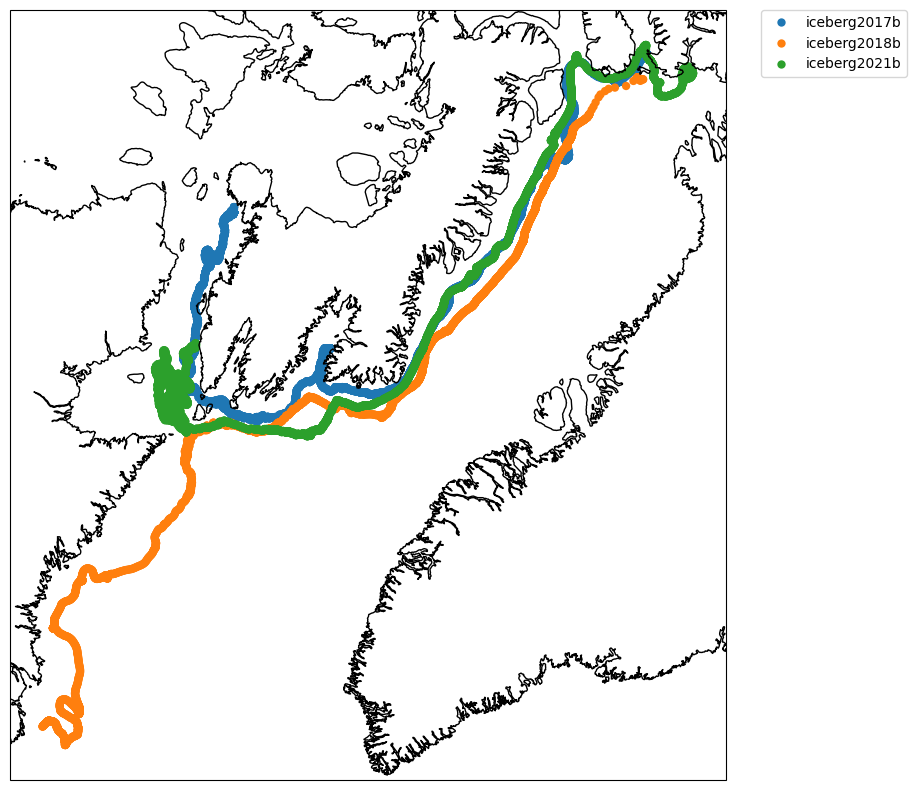

In [42]:
plot_traj_id(df_sub)

#### Read Baffin Bay data (Crawford) which should contain the 2011 ice island but doesnt

In [43]:


files_l = glob.glob("./CCIN13340_20250622_data/data/2011/**/*.json",recursive=True)


for f in files_l:
    with open(f, "r") as file:
        data = json.load(file)
        print(data['identifier_metadata']['id'],
              data['morphology_metadata']['shape'],
              data['morphology_metadata']['size'],)
            #   data['comments_metadata']['comments'],)
    # print(data["name"])

#### Read East greenland ice island

In [44]:
df = pd.read_csv('./observations/east_greenland/DMI_file.csv')
df = df.rename(columns={'X':'lon','Y':'lat','id':'time'})
df['time'] = pd.to_datetime(#df['DATE/TIME'],
                            # format='2012-02-11 20:32 GMT' if 'bread' in f else '%m/%d/%Y %I:%M:%S %p ')
                            df['time'],#.astype(str).str.strip(),
                            format='%Y%m%d%H%M%S',
                            # errors='coerce',
                            utc=True)

df = df.sort_values('time')
df

# irrgeular daily to 3-daily frequnecy (due to satelliet observations)

,lon,lat,time
1,-36.216375,65.478191,2024-07-06 14:17:39+00:00
26,-37.899527,65.420640,2024-07-08 19:56:48+00:00
13,-38.420804,65.281820,2024-07-09 09:06:18+00:00
0,-38.995687,64.588146,2024-07-11 14:19:51+00:00
27,-39.200661,64.479415,2024-07-12 08:57:25+00:00
14,-39.623303,64.321693,2024-07-13 20:04:59+00:00
28,-40.120453,64.134066,2024-07-15 08:49:52+00:00
16,-40.319362,63.837363,2024-07-16 09:12:58+00:00
15,-41.026822,62.940703,2024-07-18 20:13:13+00:00
33,-41.398034,62.798713,2024-07-20 08:59:09+00:00


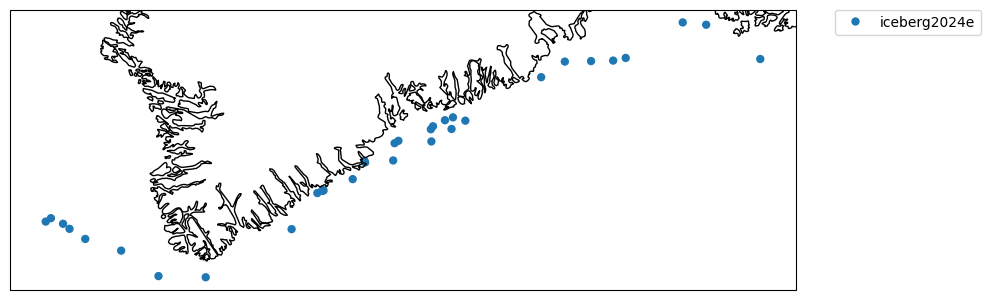

In [45]:
df_sub = df
df_sub['trajectory_id'] = 'iceberg2024e'
plot_traj_id(df_sub)
dfs.append(df_sub)

## Merge into one dataset and save

In [46]:
print(len(dfs))

5


In [47]:
# --- Merge datasets ---
merged = pd.concat(dfs,ignore_index=True)

In [48]:
merged['trajectory_id'].unique()

<ArrowStringArray>
[ 'iceberg2025w', 'iceberg2011w2', 'iceberg2011w1',  'iceberg2021w',
  'iceberg2017b',  'iceberg2018b',  'iceberg2021b',  'iceberg2024e']
Length: 8, dtype: str

In [49]:
# # Reduce memory

# merged["lat"] = merged["lat"].astype("float32")
# merged["lon"] = merged["lon"].astype("float32")

# merged["trajectory_id"] = (
#     merged["trajectory_id"]
#     .astype("category")
# )
# merged.info(memory_usage="deep")

In [50]:
#Sort
merged = merged.sort_values(
    ["trajectory_id", "time"]
)

In [53]:
ib_obs_info = {
'iceberg2011w1':{},
'iceberg2011w2':{},
'iceberg2021w':{'length':220,'obs_frequnecy':'irregular','name':'Disko Bay 11_DSE'},
'iceberg2025w':{'length':200,'width':85,'shape':'tabular','obs_frequnecy':'6H','name':'Juliette'},
'iceberg2011b':{'length':2300,'width':850,'shape':'triangular','draft':90,'comment':
'Draft set to 90m to avoid grounding','name':'Baffin Bay ice island'},
'iceberg2017b':{'length':315,'width':215,'shape':'tabular','draft':70,'comment':'draft set at 70 m in accordance with the surrounding bathymetry','obs_frequnecy':'1H'},
'iceberg2018b':{'length':269,'width':204,'shape':'tabular','draft':60,'obs_frequnecy':'1H'},
'iceberg2021b':{'length':310,'width':300,'shape':'tabular','draft':70,'obs_frequnecy':'1H'},
'iceberg2024e':{'length':4000,'width':2000,'shape':'tabular','draft':70,'obs_frequnecy':'','name':'East greenland ice island'},
}

In [54]:
#Convert to xarray
trajid_uniq = [str(s) for s in merged.trajectory_id.astype(str).values.unique()]
trajid_full = [str(s) for s in merged.trajectory_id.astype(str).values]

ds = xr.Dataset(
    data_vars=dict(
        trajectory_id_var=("time",trajid_full),
        lat=("time", merged.lat.values),
        lon=("time", merged.lon.values),
        length=("iceberg", [ib_obs_info[k].get("length", np.nan) for k in trajid_uniq]),
        width=("iceberg", [ib_obs_info[k].get("width", np.nan) for k in trajid_uniq]),
        draft=("iceberg", [ib_obs_info[k].get("draft", np.nan) for k in trajid_uniq]),
        shape=("iceberg", [ib_obs_info[k].get("shape", 'nan') for k in trajid_uniq]),
        obs_freq=("iceberg", [ib_obs_info[k].get("obs_frequnecy", 'nan') for k in trajid_uniq]),
        comment=("iceberg", [ib_obs_info[k].get("comment", 'nan') for k in trajid_uniq]),
        long_name=("iceberg", [ib_obs_info[k].get("name", 'nan') for k in trajid_uniq])
    ),
    coords=dict(
        time=("time", merged.time.values),
        trajectory_id=("time",trajid_full),
        iceberg=('iceberg', trajid_uniq)
    )
)
ds.attrs['title'] = "Merged iceberg observations dataset, sort by trajectory_id"
ds.trajectory_id.attrs['long_name'] = "Iceberg trajectory identifier along time dimension"
ds.iceberg.attrs['long_name'] = "Unique iceberg identifiers"
ds.trajectory_id_var.attrs['long_name'] = "Iceberg trajectory identifier along time dimension as variable"



In [55]:
ds.info

<bound method Dataset.info of <xarray.Dataset> Size: 3MB
Dimensions:            (time: 26799, iceberg: 8)
Coordinates:
  * time               (time) datetime64[ns] 214kB 2011-09-26T15:14:00 ... 20...
    trajectory_id      (time) <U13 1MB 'iceberg2011w1' ... 'iceberg2025w'
  * iceberg            (iceberg) <U13 416B 'iceberg2011w1' ... 'iceberg2025w'
Data variables:
    trajectory_id_var  (time) <U13 1MB 'iceberg2011w1' ... 'iceberg2025w'
    lat                (time) float64 214kB 73.06 73.0 73.0 ... 71.66 71.55
    lon                (time) float64 214kB -56.78 -56.21 ... -69.12 -68.99
    length             (iceberg) float64 64B nan nan 315.0 ... 220.0 4e+03 200.0
    width              (iceberg) float64 64B nan nan 215.0 ... nan 2e+03 85.0
    draft              (iceberg) float64 64B nan nan 70.0 60.0 70.0 nan 70.0 nan
    shape              (iceberg) <U7 224B 'nan' 'nan' ... 'tabular' 'tabular'
    obs_freq           (iceberg) <U9 288B 'nan' 'nan' '1H' ... '' '6H'
    comment      

In [56]:
#Save to netcdf

encoding = {
    "lat": {"zlib": True},
    "lon": {"zlib": True}
}

ds.to_netcdf(
    "merged_obs.nc",
    encoding=encoding
)


## Analyse which datetimes to start simulations from

Choice of seeding date-times influences the simulation results, e.g. in the polar plots. Choosing a larger number of seedings in problematic regions probably decreases the average simulation accuracy. Maybe rather stick to regular frequnecy (e.g. 2 Days) with filter for coastline distance. Then iceberg max age is similar to the frequnecy. Maybe vary frequnecy from case to case with complexity and observation period.

The observations are also a (kind of random) subset.

In [173]:
d1,d2 = ds_sub.time[[0,-1]].astype(str)
str(d1.values)

'2011-09-26T15:14:00.000000000'

In [ ]:
def find_date_idx(dates_in,ds_in):
    idx = [
        np.where(ds_in.time.dt.floor("D") == np.datetime64(d))[0][0]
        for d in dates_in
        if (ds_in.time.dt.floor("D") == np.datetime64(d)).any()
    ]
    return np.array(idx)
#test
# dates = ["2024-08-02", "2024-08-05"]
# ds_sub.time[find_date_idx(dates,ds_sub)]

def find_date_idx2(ds_in,freq_in='D'):
    d1,d2 = ds_in.time[[0,-1]]
    d1,d2 = str(d1.values),str(d2.values)
    d1d2 = np.arange(d1,d2,dtype='datetime64[%s]'%freq_in)
    idx = [
        np.where(ds_in.time.dt.floor(freq_in) == np.datetime64(d))[0][0]
        for d in d1d2
        if (ds_in.time.dt.floor(freq_in) == np.datetime64(d)).any()
    ]
    return np.array(idx)
#test
# ds_sub.time[find_date_idx2(ds_sub,freq_in='3D')]

#other resampling methods
#resampling
# ds_sub_re = ds_sub.resample(time="1D").nearest() #changes to T0:00
# ds_sub_re = (ds_sub.groupby(ds_sub.time.dt.floor("3D")).map(lambda x: x.isel(time=0)))#NOT EVERY 3D EITHER!!

<xarray.DataArray 'time' (time: 46)> Size: 368B
array(['2011-09-26T15:14:00.000000000', '2011-09-29T00:04:00.000000000',
       '2011-10-02T00:17:00.000000000', '2011-10-05T00:04:00.000000000',
       '2011-10-08T00:15:00.000000000', '2011-10-11T00:04:00.000000000',
       '2011-10-14T00:15:00.000000000', '2011-10-17T00:00:00.000000000',
       '2011-10-20T00:04:00.000000000', '2011-10-23T00:13:00.000000000',
       '2011-10-26T01:12:00.000000000', '2011-10-29T00:12:00.000000000',
       '2011-11-01T03:23:00.000000000', '2011-11-04T00:11:00.000000000',
       '2011-11-07T01:06:00.000000000', '2011-11-10T00:08:00.000000000',
       '2011-11-13T00:11:00.000000000', '2011-11-16T04:05:00.000000000',
       '2011-11-19T00:07:00.000000000', '2011-11-22T00:13:00.000000000',
       '2011-11-25T00:10:00.000000000', '2011-11-28T04:18:00.000000000',
       '2011-12-01T00:23:00.000000000', '2011-12-04T03:15:00.000000000',
       '2011-12-07T00:24:00.000000000', '2011-12-10T00:16:00.000000000',
       '2011-12-13T00:20:00.000000000', '2011-12-16T01:19:00.000000000',
       '2011-12-19T00:17:00.000000000', '2011-12-22T00:26:00.000000000',
       '2011-12-25T00:30:00.000000000', '2011-12-28T01:23:00.000000000',
       '2011-12-31T00:22:00.000000000', '2012-01-03T00:36:00.000000000',
       '2012-01-06T00:24:00.000000000', '2012-01-09T00:37:00.000000000',
       '2012-01-12T00:27:00.000000000', '2012-01-15T00:18:00.000000000',
       '2012-01-18T00:26:00.000000000', '2012-01-21T00:28:00.000000000',
       '2012-01-24T01:35:00.000000000', '2012-01-27T00:31:00.000000000',
       '2012-01-30T02:28:00.000000000', '2012-02-02T00:29:00.000000000',
       '2012-02-05T00:31:00.000000000', '2012-02-08T00:25:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time           (time) datetime64[ns] 368B 2011-09-26T15:14:00 ... 2012-02...
    trajectory_id  (time) <U13 2kB 'iceberg2011w1' ... 'iceberg2011w1'
    iceberg        <U13 52B 'iceberg2011w1'

In [157]:
ds = xr.open_dataset('./merged_obs.nc')
print(ds.iceberg.values)
ds

['iceberg2011w1' 'iceberg2011w2' 'iceberg2017b' 'iceberg2018b'
 'iceberg2021b' 'iceberg2021w' 'iceberg2024e' 'iceberg2025w']


<xarray.Dataset> Size: 3MB
Dimensions:            (time: 26799, iceberg: 8)
Coordinates:
  * time               (time) datetime64[ns] 214kB 2011-09-26T15:14:00 ... 20...
    trajectory_id      (time) <U13 1MB ...
  * iceberg            (iceberg) <U13 416B 'iceberg2011w1' ... 'iceberg2025w'
Data variables:
    trajectory_id_var  (time) <U13 1MB ...
    lat                (time) float64 214kB ...
    lon                (time) float64 214kB ...
    length             (iceberg) float64 64B ...
    width              (iceberg) float64 64B ...
    draft              (iceberg) float64 64B ...
    shape              (iceberg) <U7 224B ...
    obs_freq           (iceberg) <U9 288B ...
    comment            (iceberg) <U63 2kB ...
    long_name          (iceberg) <U25 800B ...
Attributes:
    title:    Merged iceberg observations dataset, sort by trajectory_id

<xarray.Dataset> Size: 12kB
Dimensions:            (time: 90)
Coordinates:
  * time               (time) datetime64[ns] 720B 2021-08-12T19:23:57.120000 ...
    trajectory_id      (time) <U13 5kB 'iceberg2021w' ... 'iceberg2021w'
    iceberg            <U13 52B 'iceberg2021w'
Data variables:
    trajectory_id_var  (time) <U13 5kB ...
    lat                (time) float64 720B ...
    lon                (time) float64 720B ...
    length             float64 8B ...
    width              float64 8B ...
    draft              float64 8B ...
    shape              <U7 28B ...
    obs_freq           <U9 36B ...
    comment            <U63 252B ...
    long_name          <U25 100B ...
Attributes:
    title:    Merged iceberg observations dataset, sort by trajectory_id


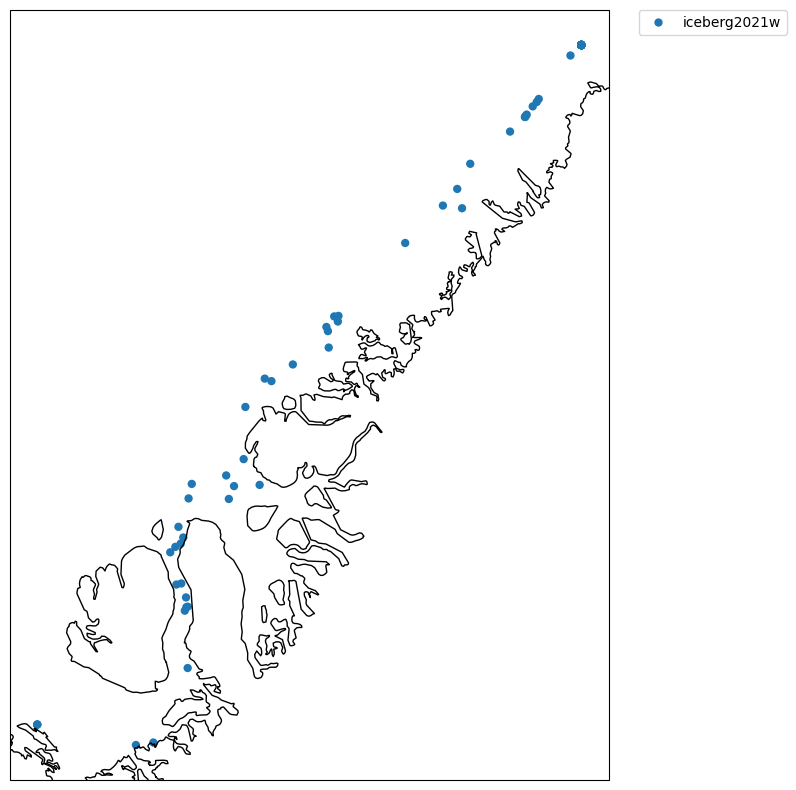

In [183]:
id = 'iceberg2021w'
ds_sub = ds.sel(iceberg=id,trajectory_id=id)
print(ds_sub)
plot_traj_id(ds_sub,'trajectory_id','tab20')

In [184]:
# time_subsets = {
#     'iceberg2024e':
#             {'custom': np.array(['2024-07-06', '2024-07-08', '2024-07-09', '2024-07-11', '2024-07-13', '2024-07-16', 
#             '2024-07-18', '2024-07-26', '2024-07-28', '2024-07-30', '2024-08-05', '2024-08-11', 
#             '2024-08-14', '2024-08-15', '2024-08-16', '2024-08-17', '2024-08-18','2024-08-20'],dtype='datetime64[D]'),
#             '2D':np.arange('2024-07-06','2024-08-23',dtype='datetime64[2D]')},
#     'iceberg2025w':
#             {'2D':np.arange('2025-09-24','2025-12-10',dtype='datetime64[2D]'),
#              'custom':np.array(['2025-09-29','2025-10-05','2025-10-11','2025-10-13','2025-10-15','2025-10-17',
#                 '2025-10-19','2025-10-21','2025-10-23','2025-10-25', '2025-10-27','2025-10-31',
#                 '2025-11-08','2025-11-10','2025-11-14','2025-11-18', '2025-11-22','2025-11-26',
#                 '2025-11-28','2025-11-30','2025-12-02','2025-12-04','2025-12-06','2025-12-08'],dtype='datetime64[D]')},
#     'iceberg2021b':
#             {'2D':np.arange('2021-09-03','2022-08-15',dtype='datetime64[10D]')   }#even less?
            
# }
# #those can be used as de: ds_sub.isel(time=find_date_idx(de,ds_sub)



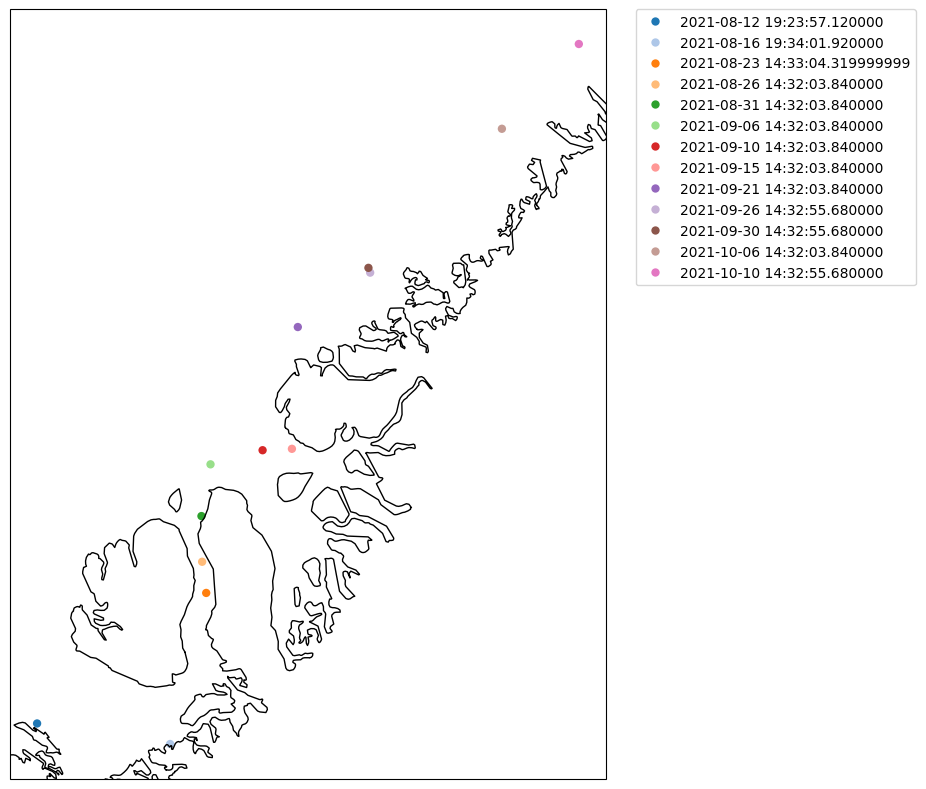

<xarray.DataArray 'time' (time: 13)> Size: 104B
array(['2021-08-12T19:23:57.120000000', '2021-08-16T19:34:01.920000000',
       '2021-08-23T14:33:04.319999999', '2021-08-26T14:32:03.840000000',
       '2021-08-31T14:32:03.840000000', '2021-09-06T14:32:03.840000000',
       '2021-09-10T14:32:03.840000000', '2021-09-15T14:32:03.840000000',
       '2021-09-21T14:32:03.840000000', '2021-09-26T14:32:55.680000000',
       '2021-09-30T14:32:55.680000000', '2021-10-06T14:32:03.840000000',
       '2021-10-10T14:32:55.680000000'], dtype='datetime64[ns]')
Coordinates:
  * time           (time) datetime64[ns] 104B 2021-08-12T19:23:57.120000 ... ...
    trajectory_id  (time) <U13 676B 'iceberg2021w' ... 'iceberg2021w'
    iceberg        <U13 52B 'iceberg2021w'

In [185]:
#time subset, finally
# ds_sub_re = ds_sub.isel(time=find_date_idx(timesubsets['iceberg2024e'],ds_sub))
# ds_sub_re = ds_sub.isel(time=find_date_idx(np.arange('2024-07-06','2024-08-23',dtype='datetime64[2D]'),ds_sub))
# ds_sub_re = ds_sub.isel(time=find_date_idx(time_subsets[id]['2D'],ds_sub))
ds_sub_re = ds_sub.isel(time=find_date_idx2(ds_sub,freq_in='5D'))
plot_traj_id(ds_sub_re,'time','tab20')
ds_sub_re.time

Analysis results:
- iceberg2024e: 
    - original resolution (1-3daily): full data
    - 2 daily (conserving individual timestamp, where 2nd day available)
    - custom (suitable datetime selected from map) 
-iceberg 2025w (Juliette):
    - (original resolution - 6 hourly - too much)
    - daily, 2 daily
    - custom (approx. 2 daily)

## Distance to land

In [39]:
import xarray as xr
ds = xr.open_dataset("./input/GEBCO/gebco_2026_n85.0_s35.0_w-80.0_e0.0.nc")
bath = ds["elevation"]

In [40]:
bath

<xarray.DataArray 'elevation' (lat: 12000, lon: 19200)> Size: 922MB
[230400000 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 96kB 35.0 35.01 35.01 35.01 ... 84.99 84.99 85.0
  * lon      (lon) float64 154kB -80.0 -79.99 -79.99 ... -0.00625 -0.002083
Attributes:
    long_name:           Elevation relative to sea level
    grid_mapping:        crs
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_uom_name:        Metres
    sdn_uom_urn:         SDN:P06::ULAA
    standard_name:       height_above_mean_sea_level
    units:               m

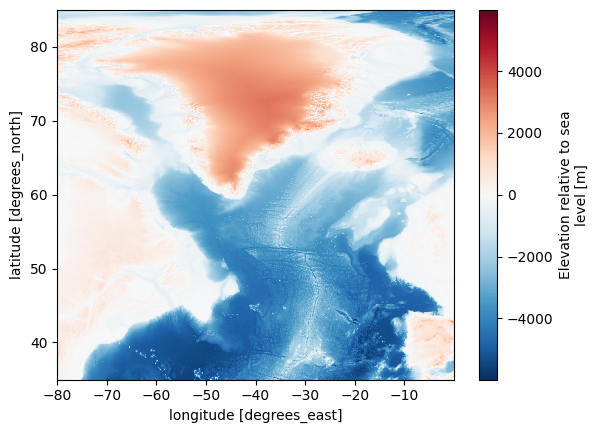

In [41]:
bath[::10,::10].plot() #This shows that land has positive height, water negative

In [42]:
land_mask = bath >= 0

In [43]:
from scipy.ndimage import binary_dilation
ocean_mask = ~land_mask
# coast_mask = land_mask & binary_dilation(ocean_mask)# here costaline point on land
coast_mask = ocean_mask & binary_dilation(land_mask) #here costline point in ocean
#
coast_y, coast_x = np.where(coast_mask)
coast_lats = ds.lat[coast_y]
coast_lons = ds.lon[coast_x]
#or
lon2d, lat2d = np.meshgrid(ds.lon, ds.lat)
coast_points = np.column_stack([
    lat2d[coast_mask],
    lon2d[coast_mask]
])


In [44]:
coast_points

array([[ 35.00208333, -76.97291667],
       [ 35.00208333, -76.87708333],
       [ 35.00208333, -76.86875   ],
       ...,
       [ 83.67291667, -34.11041667],
       [ 83.67291667, -34.10625   ],
       [ 83.67291667, -34.10208333]], shape=(736204, 2))

In [45]:
#nearest-neighbour search tree using haversine distance
from sklearn.neighbors import BallTree

coast_radians = np.radians(coast_points)

tree = BallTree(
    coast_radians,
    metric="haversine"
)

import pickle
with open("./input/GEBCO/coast_tree.pkl", "wb") as f:
    pickle.dump(tree, f)

In [46]:
#grid interpolator??
from scipy.interpolate import RegularGridInterpolator

interp = RegularGridInterpolator(
    (ds.lat.values, ds.lon.values),
    bath.values,
    bounds_error=False,
    fill_value=np.nan
)

import joblib
joblib.dump(interp, "./input/GEBCO/gebco_interp.joblib")

['./input/GEBCO/gebco_interp.joblib']

In [47]:
#COASTLINE CHECK
EARTH_RADIUS_KM = 6371.0

def coast_distance_km(lat, lon, tree="./input/GEBCO/coast_tree.pkl"):
    query = np.radians(
        np.column_stack([lat, lon])
    )
    dist_rad, ind = tree.query(
        query,
        k=1
    )
    return dist_rad[:, 0] * EARTH_RADIUS_KM



In [48]:
#Bathymerty check
def bathymetry_depth(lat, lon, interp="./input/GEBCO/gebco_interp.joblib"):

    pts = np.column_stack([lat, lon])

    return interp(pts)


In [54]:
print(np.mean(check_coast))#relative number of observation points far enough from land
print(np.mean(check_bathy))#relative number of observation points deep enough

0.7156610321280645
0.862718758162618


## Full workflow


In [60]:
ds.iceberg

<xarray.DataArray 'iceberg' (iceberg: 8)> Size: 416B
array(['iceberg2011w1', 'iceberg2011w2', 'iceberg2017b', 'iceberg2018b',
       'iceberg2021b', 'iceberg2021w', 'iceberg2024e', 'iceberg2025w'],
      dtype='<U13')
Coordinates:
  * iceberg  (iceberg) <U13 416B 'iceberg2011w1' ... 'iceberg2025w'
Attributes:
    long_name:  Unique iceberg identifiers

In [96]:
import xarray as xr
from  coast_bathy_check import *

interp = joblib.load("./input/GEBCO/gebco_interp.joblib")
tree = pickle.load(open("./input/GEBCO/coast_tree.pkl", "rb"))

id = 'iceberg2018b'
ds = xr.open_dataset('./merged_obs.nc')
ds_sub = ds.sel(iceberg=id,trajectory_id=id)
# ds_sub_re = ds_sub.isel(time=find_date_idx2(ds_sub,freq_in='3D'))

In [97]:
# bathy and coastline check, APPLY BATHY FIRST, THEN RESAMPLE TIME!
check_coast = (coast_distance_km(ds_sub.lat, ds_sub.lon)>12.5)
check_bathy = ((bathymetry_depth(ds_sub.lat, ds_sub.lon)+(ds_sub.draft.values*1.5))<0)#since bath neg and draft pos
check_bathy = True #disables check_bathy
ds_sub_bath = ds_sub.sel(time=np.logical_and(check_coast,check_bathy))
ds_sub_bath = ds_sub_bath.isel(time=find_date_idx2(ds_sub_bath,freq_in='15D'))

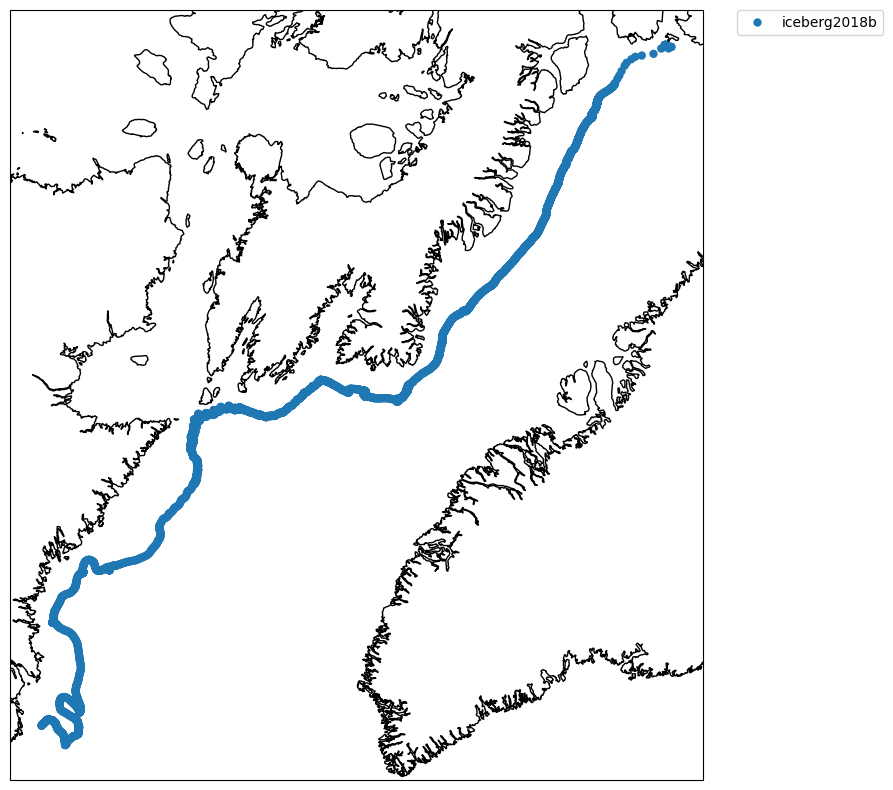

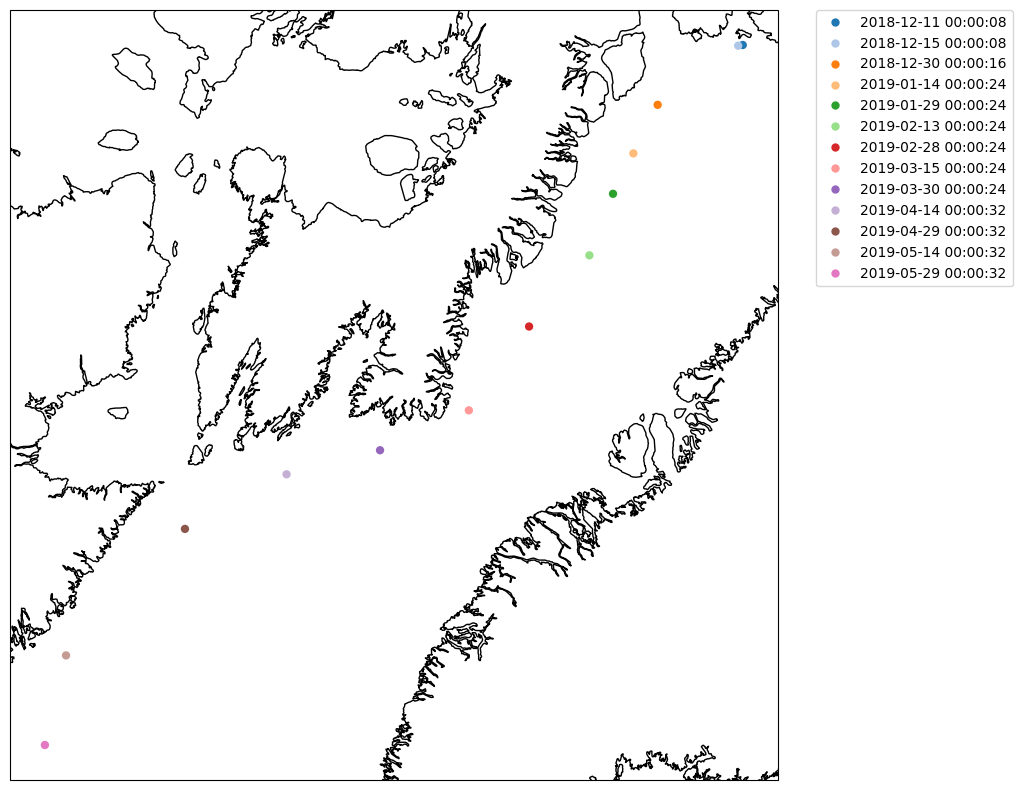

In [98]:
#plot original and selected points

plot_traj_id(ds_sub,'trajectory_id')
# plot_traj_id(ds_sub_re,'time','tab20')
plot_traj_id(ds_sub_bath,'time','tab20')

Now I need o think about what to do if seeding time-position is not suitable:

- 1) apply coastline check (12.5km according to lowest resolution input), similar for all simulations
- 2) bathy check?- no, allows them to melt, filter out by status or velocity later
- 3) then resample time, choose frequency to be represnetative for individual trajectory
- 4) leadtime according to freqeuncy (might be too short here and there)
- -> make sure enough points remain

Filters for seeding position-dates: (see above for standard)
- 3D: iceberg2024e, iceberg2025w, iceberg2011w1, iceberg2011w2, iceberg2021w
- 15D:  iceberg2018b, iceberg2017b
- drop: (iceberg2021b)